<h1 style="color: Cyan;">Netflix Movies & TV Shows — Trend Analysis & Exploratory Analytics</h1>

**Author:** <p style="color: Cyan;">Diyor — Data Scientist, Processing Centre</p>
**Date:** <p style="color: Cyan;">March 7th, 2026</p>

**Summary:**  
<p style="font-size: 18px">This notebook performs a full exploratory data analysis on the Netflix Movies and TV Shows <a href="https://www.kaggle.com/datasets/shivamb/netflix-shows">dataset</a> from Kaggle. I investigate content composition, yearly trends, geographic distribution, genre patterns, and year‑over‑year growth to extract actionable business insights for a streaming analytics team. All analysis uses Python, pandas, matplotlib, and seaborn.</p>
<hr>

<h2 style="color: Cyan;">1. Data Loading & Inspection</h2>
<p style="font-size: 18px">I start by importing the three libraries required for this task — <b>pandas</b> for data manipulation, <b>matplotlib</b> for charting, and <b>seaborn</b> for statistical visualisation. Then I set a global visual style so every chart in the notebook looks consistent without me repeating styling code.</p>
<hr>

In [73]:
# I import only the libraries specified in the task requirements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I set a global style for all my plots so the notebook looks clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 2)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("\033[1m\033[92mLibraries imported and visual config set.\033[0m")

Libraries imported and visual config set.


<hr>

In [74]:
# I load the Netflix dataset from the CSV file
df = pd.read_csv("./dataset/netflix_titles.csv", delimiter=",")

def show_basic_info(df: pd.DataFrame) -> None:
    """I print the basic shape and info about the dataset"""
    rows = df.shape[0]
    cols = df.shape[1]
    print(f"\n\033[1m\033[92mDataset shape:\033[0m \033[95m{rows} rows × {cols} columns\033[0m")

show_basic_info(df)


Dataset shape: 8807 rows × 12 columns


In [75]:
# I look at the first 5 rows to understand the structure
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [76]:
# I check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [77]:
# I get summary statistics for all columns
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


<h2 style="color: Cyan;">Inspection Summary:</h2>  
<p style="font-size: 18px;">The dataset contains <b style="color: Cyan;">8,807</b> rows and 12 columns. I can see missing values in <b style="color: Cyan;">director</b>, <b style="color: Cyan;">cast</b>, <b style="color: Cyan;">country</b>, and <b style="color: Cyan;">date_added</b>. The <b style="color: Cyan;">date_added</b> column is stored as a string (object) and needs conversion to datetime. The <b style="color: Cyan;">listed_in</b> column contains comma-separated genres that I will need to split later for genre-level analysis.</p>
<hr>

<h2 style="color: Cyan;">2. Data Cleaning</h2>  
<h3 style="color: Cyan;">2.1. Remove Duplicates</h3>

<p style="font-size: 18px">I check for duplicate rows based on <b style="color: Cyan;">show_id</b>, which should be unique for every title.</p>

In [78]:
def check_and_remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """I check for duplicates by show_id and remove them"""
    duplicates = df.duplicated(subset="show_id").sum()
    print(f"\n\033[1m\033[92mDuplicate rows found:\033[0m \033[95m{duplicates}\033[0m")
    
    df_clean = df.drop_duplicates(subset="show_id").reset_index(drop=True)
    print(f"\033[1m\033[92mRows after cleanup:\033[0m \033[95m{df_clean.shape[0]}\033[0m")

    return df_clean

df = check_and_remove_duplicates(df)


Duplicate rows found: 0
Rows after cleanup: 8807


<p style="font-size: 18px;">I found zero duplicate rows based on <b style="color: Cyan;">show_id</b>, which means every entry in the dataset is unique. Even though nothing was removed, running this check is important — it confirms the data integrity before I proceed.</p>
<hr>

<h2 style="color: Cyan;">2.2 Convert <b>date_added</b> to Datetime</h2>
<p style="font-size: 18px;">The <b style="color: Cyan;">date_added</b> column is the backbone of all time-series analysis. I use <b style="color: Cyan;">errors='coerce</b> so unparseable dates become NaT instead of crashing.</p>

In [79]:
def convert_date_column(df: pd.DataFrame) -> pd.DataFrame:
    """I convert date_added from string to datatime"""
    df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
    missing_dates = df["date_added"].isna().sum()
    print(f"\n\033[1m\033[92mEntries with missing/unparseable dates:\033[0m \033[95m{missing_dates}\033[0m")

    return df

df = convert_date_column(df)


Entries with missing/unparseable dates: 98


<h2 style="color: Cyan;">2.3 Handle Missing Values</h2>
<p style="font-size: 18px;">I first inspect which columns have missing data and how much, then decide on a fill strategy for each one.</p>

In [80]:
def show_missing_values(df: pd.DataFrame) -> None:
    """I show which columns have missing values and how many"""
    missing = df.isnull().sum()
    missing_percentage = (missing / len(df) * 100).round(2)

    for col in df.columns:
        if missing[col] > 0:
            print(f"\033[1m\033[92m{col}:\033[0m \033[95m{missing[col]} missing ({missing_percentage[col]}%)\033[0m")

show_missing_values(df)


director: 2634 missing (29.91%)
cast: 825 missing (9.37%)
country: 831 missing (9.44%)
date_added: 98 missing (1.11%)
rating: 4 missing (0.05%)
duration: 3 missing (0.03%)


In [81]:
def fill_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """I fill missing values with appropriate placeholders"""
    # I fill these with placeholders cause dropping them would lose too much data
    df["director"] = df["director"].fillna("Not Available")
    df["cast"] = df["cast"].fillna("Not Available")
    df["country"] = df["country"].fillna("Unknown")
    df["rating"] = df["rating"].fillna("Not Available")
    df["duration"] = df["duration"].fillna("Not Available")
    
    print(f"\n\033[1m\033[92mMissing values filled successfully.\033[0m")

    return df

df = fill_missing_values(df)


Missing values filled successfully.


<h2 style="color: Cyan;">Missing value strategy:</h2> 
<ul>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">country</b> — I fill with <b style="color: Cyan;">'Unknown'</b> so these rows still participate in non-geographic analyses.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">director / cast</b> — Filled with <b style="color: Cyan;">'Not Available'</b> since I will not analyse director or cast trends in this task.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">rating / duration</b> — Also filled with <b style="color: Cyan;">'Not Available'</b> to keep the dataframe complete, so these fields are not central to the trend analyses required.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">date_added</b> — I do not fill this column. Rows without a date are excluded from time-based analysis but kept for non-temporal tasks like content counts and genre analysis.</p>
    </li>
</ul>

<hr>

<h2>2.4 Create New Columns: <b style="color: Cyan;">year_added</b> and <b style="color: Cyan;">month_added</b></h2>
These derived columns are my primary grouping keys for all trend analysis.

In [82]:
def create_time_columns(df: pd.DataFrame) -> pd.DataFrame:
    """I extract year and month from date_added for trend analysis"""
    df["year_added"] = df["date_added"].dt.year
    df["month_added"] = df["date_added"].dt.month
    valid = df["year_added"].notna().sum()

    print(f"\n\033[1m\033[92mRows with valid year_added:\033[0m \033[95m{valid}\033[0m")

    return df

df = create_time_columns(df)


Rows with valid year_added: 8709


<hr>

<h2 style="color:Cyan;">2.5 Handle Multi-Genre Listings</h2>
<p style="font-size:18px;">The <b style="color:Cyan;">listed_in</b> column contains comma-separated genres. I create a separate exploded dataframe specifically for genre analysis, keeping the main dataframe unchanged to avoid inflating row counts.</p>

In [84]:
def create_genre_datadrame(df: pd.DataFrame) -> pd.DataFrame:
    """I split multi-genre entries into separate rows genre analysis"""
    df_genres = df.copy()
    df_genres["genre"] = df_genres["listed_in"].str.split(", ")
    df_genres = df_genres.explode("genre")
    df_genres["genre"] = df_genres["genre"].str.split()

    print(f"\n\033[1m\033[92mOriginal dataframe:\033[0m \033[95m{len(df)} rows\033[0m")
    print(f"\033[1m\033[92mExploded genre dataframe:\033[0m \033[95m{len(df_genres)} rows\033[0m")

    return df_genres

df_genres = create_genre_datadrame(df)


Original dataframe: 8807 rows
Exploded genre dataframe: 19323 rows


<h2 style="color: Cyan;">Cleaning Summary:</h2>
<p style="font-size: 18px;">All cleaning steps are now complete. Here is a summary of what I did:</p>
<ol>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">Duplicates</b> — Checked for duplicates by <b style="color: Cyan;">'show_id'</b> none were found.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">Datetime conversion</b> — Converted <b style="color: Cyan;">'date_added'</b> from string to datetime using <b style="color:Cyan;">pd.to_datetime()</b></p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">Missing values</b> — Filled <b style="color: Cyan;">'country'</b> <b style="color: Cyan;">'director'</b>, <b style="color: Cyan;">'cast'</b>, <b style="color: Cyan;">'rating'</b>, and <b style="color: Cyan;">'duration'</b> with appropriate placeholders. Left <b style="color: Cyan;">'date_added'</b> NaT values in place for exclusion during time-series analysis.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">New columns</b> — Created <b style="color: Cyan;">'year_added'</b> and <b style="color: Cyan;">'month_added'</b> by extracting from the datetime column.</p>
    </li>
    <li>
    <p style="font-size:18px;"><b style="color: Cyan;">Genre explosion</b> — Created a separate <b style="color: Cyan;">'df_genres'</b> dataframe where multi-genre entries are split into individual rows.</p>
    </li>
</ol>

<hr>

<h2 style="color:Cyan;">3. Exploratory Data Analysis (EDA)</h2>
<h3>3.1 Content Counts — Movies vs TV Shows</h3>
<p style="><b>Question:</b></p>

<p style="font-size: 18px;"><b style="color: Cyan;">Question:</b> How is the Netflix catalogue split between Movies and TV Shows?</p>

In [98]:
def get_content_counts(df: pd.DataFrame) -> pd.Series:
    """I count MOvies and TV Shows"""
    counts = df["type"].value_counts()
    total = counts.sum()
    
    for content_type in counts.index:
        percentage = (counts[content_type] / total * 100).round(2)
        print(f"\033[1m\033[92m{content_type}:\033[0m \033[95m{counts[content_type]} ({percentage}%)\033[0m")
    
    return counts

type_counts = get_content_counts(df)


Movie: 6131 (69.62%)
TV Show: 2676 (30.38%)


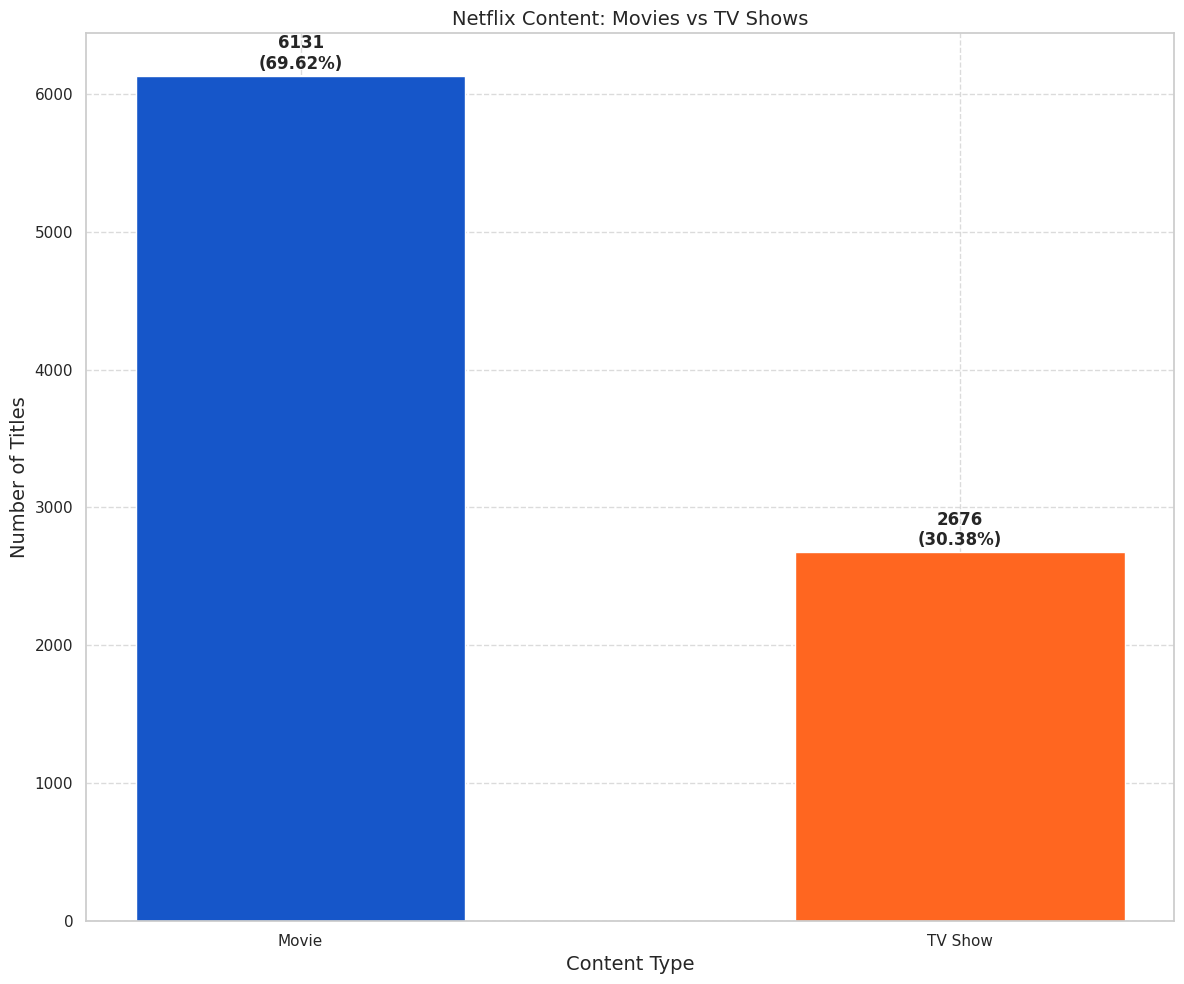

In [ ]:
def plot_content_counts(type_counts: pd.Series) -> None:
    """My function (method) creates a bar chart showing Movies vs TV Shows split"""
    fig, ax = plt.subplots(figsize=(12, 10))
    colours = ['#1656C9', '#FF6620']
    bars = ax.bar(type_counts.index, type_counts.values, color=colours, edgecolor="white", width=0.5)

    # I calculate the total to compute percentages
    total = type_counts.sum()

    for bar, count in zip(bars, type_counts.values):
        percentage = round(count / total * 100, 2)
        # I figure out where to place the text - horizontally centered on the bar
        left_edge = bar.get_x()        # where the bar starts on the x-axis
        bar_width = bar.get_width()    # how wide the bar is
        x_centre = left_edge + bar_width / 2 # the middle point of the bar

        # I figure out where to place the text - vertically just above the bar
        bar_top = bar.get_height()     # how tall the bar is (its top edge)
        y_above = bar_top + 20         # I add 20 to push the text a bit higher

        # I build the text I want to display
        label = f"{count}\n({percentage}%)"

        # I place the text on the chart
        ax.text(
            x_centre,
            y_above,
            label,
            ha='center',
            va='bottom',
            fontweight='bold'
        )

    # Display the chart
    ax.set_title("Movies vs TV Shows")
    ax.set_ylabel("Count")
    ax.set_title("Netflix Content: Movies vs TV Shows")
    ax.set_ylabel("Number of Titles", fontsize=14)
    ax.set_xlabel("Content Type", fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_content_counts(type_counts)